In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


# Amber benchmark CAMI II marine pooled

* Source: https://usegalaxy.eu/u/paulzierep/h/copy-of-fairymags-taxonomic-binning-evaluation-pooled

/tmp/ipykernel_125172/2653748827.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_125172/2653748827.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_125172/2653748827.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_125172/2653748827.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_125172/2653748827.py:46: FutureWarnin

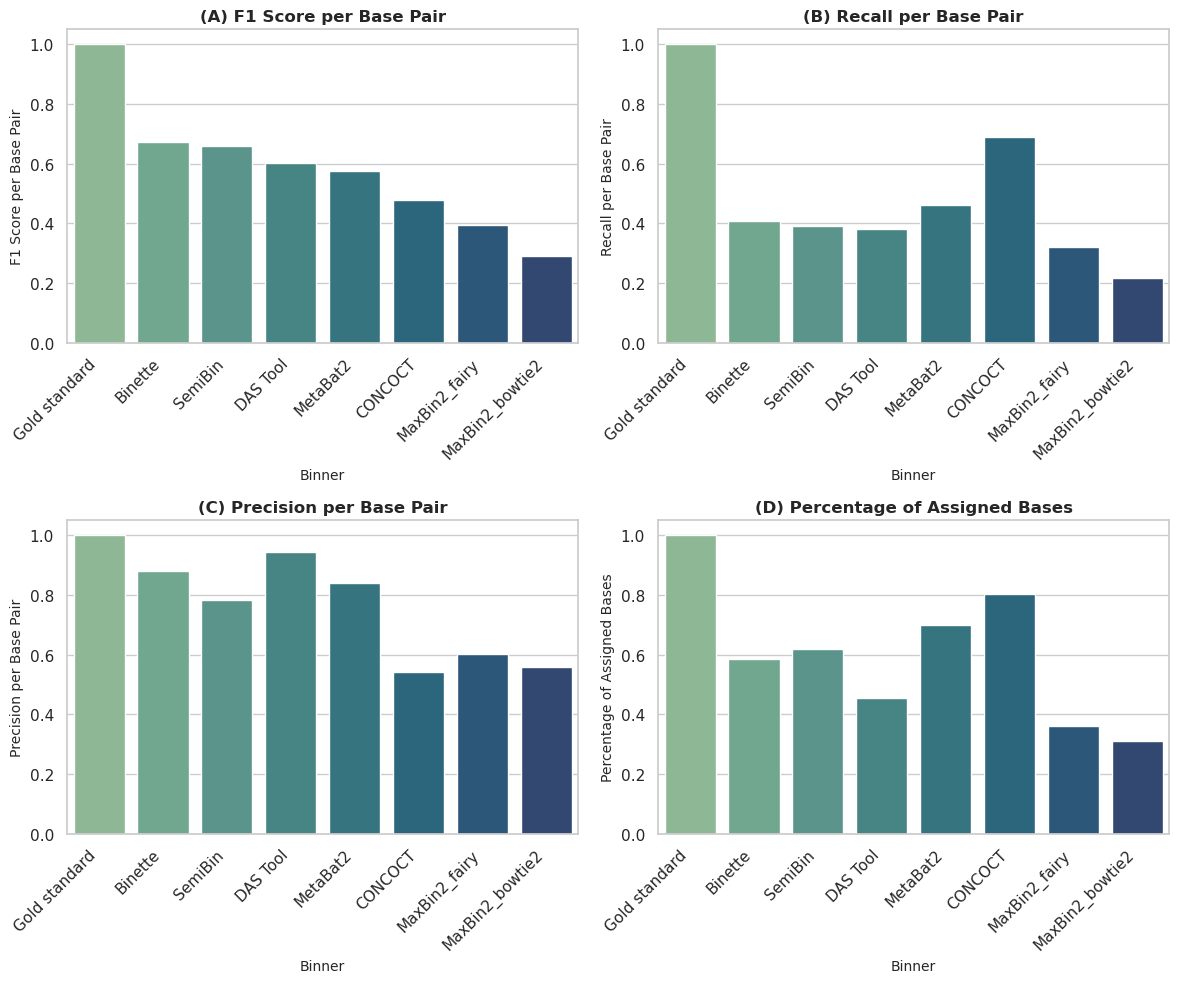

In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# URL to the TSV file
amber_results = "https://usegalaxy.eu/api/datasets/4838ba20a6d8676540e8ec86698e2f53/display?to_ext=tabular"

# Load TSV data
df = pd.read_csv(amber_results, sep='\t', index_col="Sample")

# Filter for genome binning type
df_genome = df[df['binning type'] == 'genome']

# Remove 'dRep' completely
df_genome = df_genome[~df_genome['Tool'].str.contains('dRep', case=False)]

# Clean up '_GTDB' labels
df_genome['Tool'] = df_genome['Tool'].str.replace('_GTDB', '', regex=False)
df_genome['Tool'] = df_genome['Tool'].str.replace('FAIRY', 'fairy')
df_genome['Tool'] = df_genome['Tool'].str.replace('BOWTIE2', 'bowtie2')

# Sort by F1 score descending for consistent x-axis order
df_genome = df_genome.sort_values(by='f1_score_per_bp', ascending=False)

# Set Seaborn theme
sns.set(style="whitegrid")

# Ensure output directories exist
os.makedirs('plots', exist_ok=True)

# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# Define metrics
metrics = [
    ('f1_score_per_bp', 'F1 Score per Base Pair', '(A)'),
    ('recall_avg_bp', 'Recall per Base Pair', '(B)'),
    ('precision_avg_bp', 'Precision per Base Pair', '(C)'),
    ('percentage_of_assigned_bps', 'Percentage of Assigned Bases', '(D)')
]

# Plot each metric
for ax, (col, ylabel, label) in zip(axes.flatten(), metrics):
    sns.barplot(
        data=df_genome,
        x='Tool',
        y=col,
        palette='crest',
        ax=ax
    )
    ax.set_title(f'{label} {ylabel}', fontsize=12, weight='bold')
    ax.set_xlabel('Binner', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Save figure
plt.tight_layout()
plt.savefig('plots/genome_binning_metrics_2x2_assigned_bases.png', dpi=300)
plt.savefig('plots/genome_binning_metrics_2x2_assigned_bases.svg', dpi=300)
plt.show()

# Cami II marine

* Source: https://usegalaxy.eu/u/paulzierep/h/mags-individual-workflow-cami-ii-marine-dataset

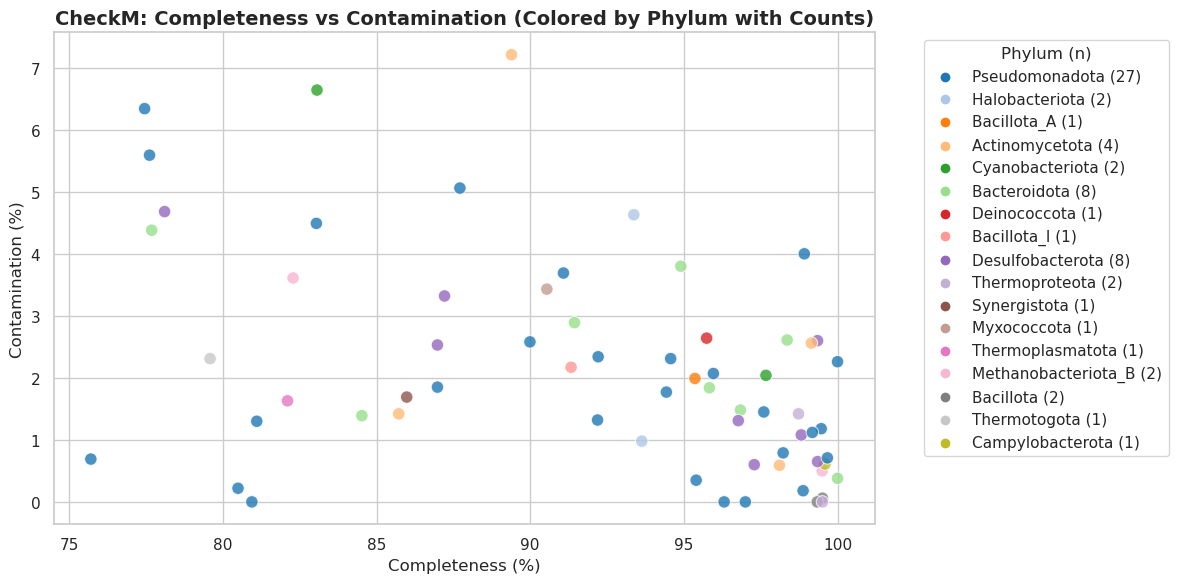

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- URLs to the TSV files ----
checkm_results = "https://usegalaxy.eu/api/datasets/4838ba20a6d8676580958701afa6c026/display?to_ext=tabular"
gtdb_results_ar = "https://usegalaxy.eu/api/datasets/4838ba20a6d86765209d6215ad7ef1ea/display?to_ext=tsv"
gtdb_results_bac = "https://usegalaxy.eu/api/datasets/4838ba20a6d86765752584718e899bc9/display?to_ext=tsv"

# ---- Load datasets with index ----
checkm_df = pd.read_csv(checkm_results, sep='\t', index_col="Bin Id")
gtdb_ar = pd.read_csv(gtdb_results_ar, sep='\t', index_col="user_genome")
gtdb_bac = pd.read_csv(gtdb_results_bac, sep='\t', index_col="user_genome")

# ---- Fix CheckM index to match GTDB style ----
checkm_df.index = checkm_df.index.str.replace('.', '_', regex=False)

# ---- Combine archaeal and bacterial GTDB results ----
gtdb_df = pd.concat([gtdb_ar, gtdb_bac], ignore_index=False)

# ---- Extract phylum from classification column ----
def extract_phylum(classification):
    try:
        return next(x for x in classification.split(';') if x.startswith('p__')).replace('p__', '').strip()
    except StopIteration:
        return None

gtdb_df['Phylum'] = gtdb_df['classification'].apply(extract_phylum)

# ---- Join GTDB phylum into CheckM based on index ----
merged_df = checkm_df.join(gtdb_df[['Phylum']])

# ---- Create a "Phylum (n)" column for labeling ----
phylum_counts = merged_df['Phylum'].value_counts()
merged_df['Phylum (n)'] = merged_df['Phylum'].map(lambda p: f"{p} ({phylum_counts[p]})" if pd.notnull(p) else "Unknown")

# ---- Plot: Completeness vs Contamination with counts in legend ----
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=merged_df,
    y='Contamination',
    x='Completeness',
    hue='Phylum (n)',
    palette='tab20',
    s=80,
    alpha=0.8
)

plt.title('CheckM: Completeness vs Contamination (Colored by Phylum)', fontsize=14, weight='bold')
plt.ylabel('Contamination (%)')
plt.xlabel('Completeness (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Phylum (n)')
plt.tight_layout()
plt.show()
